In [1]:
import os
import sys
import json
import argparse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

from glob import glob
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm.second_level import make_second_level_design_matrix
from nilearn.image import threshold_img, math_img
from nilearn.glm import threshold_stats_img

In [2]:
#from atlasreader import create_output

In [3]:
import nilearn
print('nilearn version', nilearn.__version__)

nilearn version 0.12.1


In [4]:
from nilearn import plotting, datasets, surface

# for plotting slices
mni152_template = datasets.load_mni152_template(resolution=1)
# for plotting on surface
fsaverage = datasets.fetch_surf_fsaverage('fsaverage')

[fetch_surf_fsaverage] Dataset found in /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage


In [5]:
task_label = 'badaga'
fwhm = 6.00
space_label = 'MNI152NLin2009cAsym'

# define data directories
bidsroot = os.path.join('/bgfs/bchandrasekaran/krs228/data/', 
                        'SSP/',
                        'data_bids',
                       )
nilearn_dir = os.path.join(bidsroot, 'derivatives', 'nilearn')

# Group-level analyses

Based on [nilearn documentation](https://nilearn.github.io/stable/auto_examples/05_glm_second_level/plot_thresholding.html#statistical-testing-of-a-second-level-analysis)

### Build the group-level design matrix

#### Read the `participants.tsv` file from the BIDS root directory

In [6]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')

# subjects to ignore (not fully processed, etc.) -- kept as an empty list (rather than removed
# outright) so a future one-off exclusion has somewhere to go. The previously-hardcoded
# exclusions (001/002/005/012/014/069/072/076/102, plus 058 which was unique to this notebook)
# are no longer needed: prepare_group_inputs() below already drops any subject missing a
# first-level file or covariate for a given contrast, and none of them had enough badaga task
# data on disk to produce first-level derivatives in the first place -- confirmed 2026-07-31 --
# so the graceful per-contrast check now does per-contrast what this list used to do by hand,
# all-or-nothing. sub-SSP058 specifically DOES have full badaga data and was excluded here (and
# only here -- not in group_level_all_ROI.ipynb's ignore_subs) with no recorded reason;
# confirmed safe to include.
ignore_subs = []
participants_df.drop(participants_df[participants_df.participant_id.isin(ignore_subs)].index, inplace=True)

# re-sort by participant ID
participants_df.sort_values(by=['participant_id'], ignore_index=True, inplace=True)

In [7]:
participants_df.head(10)

,participant_id,sex,group,age,toni_index,ctopp_phon_awareness,celf_core_language,celf_receptive_language,celf_expressive_language,pta,win_correct_avg,win_score_avg
0,sub-SSP001,F,control,11.164384,89.0,75.0,96.0,93.0,106.0,NaN,NaN,NaN
1,sub-SSP002,F,control,13.013699,104.0,100.0,114.0,100.0,112.0,NaN,NaN,NaN
2,sub-SSP005,F,control,10.490411,100.0,96.0,108.0,98.0,112.0,NaN,NaN,NaN
3,sub-SSP008,M,control,8.550685,104.0,98.0,113.0,117.0,120.0,NaN,NaN,NaN
4,sub-SSP009,M,control,9.879452,101.0,98.0,111.0,89.0,116.0,NaN,NaN,NaN
5,sub-SSP011,M,control,11.495890,114.0,84.0,117.0,105.0,122.0,NaN,NaN,NaN
6,sub-SSP012,M,control,12.989041,111.0,94.0,100.0,102.0,98.0,NaN,NaN,NaN
7,sub-SSP013,M,control,11.027397,99.0,71.0,85.0,77.0,89.0,NaN,NaN,NaN
8,sub-SSP014,F,control,11.528767,120.0,114.0,116.0,111.0,114.0,NaN,NaN,NaN
9,sub-SSP015,M,control,9.690411,100.0,100.0,96.0,107.0,98.0,NaN,NaN,NaN


In [8]:
participants_df.participant_id.unique

<bound method Series.unique of 0     sub-SSP001
1     sub-SSP002
2     sub-SSP005
3     sub-SSP008
4     sub-SSP009
5     sub-SSP011
6     sub-SSP012
7     sub-SSP013
8     sub-SSP014
9     sub-SSP015
10    sub-SSP017
11    sub-SSP018
12    sub-SSP020
13    sub-SSP021
14    sub-SSP028
15    sub-SSP032
16    sub-SSP033
17    sub-SSP034
18    sub-SSP036
19    sub-SSP038
20    sub-SSP039
21    sub-SSP040
22    sub-SSP041
23    sub-SSP045
24    sub-SSP046
25    sub-SSP048
26    sub-SSP051
27    sub-SSP054
28    sub-SSP056
29    sub-SSP058
30    sub-SSP060
31    sub-SSP062
32    sub-SSP064
33    sub-SSP074
34    sub-SSP076
35    sub-SSP077
36    sub-SSP078
37    sub-SSP081
38    sub-SSP083
39    sub-SSP084
40    sub-SSP085
41    sub-SSP086
42    sub-SSP089
43    sub-SSP090
44    sub-SSP091
45    sub-SSP092
46    sub-SSP093
47    sub-SSP094
48    sub-SSP095
49    sub-SSP097
50    sub-SSP099
51    sub-SSP100
52    sub-SSP102
53    sub-SSP103
54    sub-SSP106
55    sub-SSP107
56    sub-SSP111


In [9]:
# create group-specific lists of subject IDs
# group labels in participants.tsv have been observed with inconsistent casing (e.g. 'CWS' vs 'cws'),
# so compare against a case- and whitespace-normalized copy rather than the raw strings
group_norm = participants_df.group.str.strip().str.lower()
sub_list_cwns = list(participants_df.participant_id[group_norm == 'control'])
sub_list_cws = list(participants_df.participant_id[group_norm == 'cws'])

# full subject list used by every contrast section below (sorted for a deterministic file order)
subjects_label = sorted(sub_list_cwns + sub_list_cws)

#### Create confounds dataframe

**Modeling choices (recorded for reproducibility):** continuous covariates below are **mean-centered** (`x - x.mean()`), not divided by their mean and not z-scored -- this keeps covariate=0 at the sample average (so group main-effect contrasts are evaluated "at an average participant") while leaving contrast magnitudes in the covariates' original units. **Missing covariate values** are handled per-contrast, per-subject (`prepare_group_inputs`, further down): a subject is dropped only from the specific contrast's design matrix if they're missing a covariate that contrast actually uses, and the drop is logged -- not the previous behavior of silently dropping an entire covariate for every subject if even one subject was missing that value.

In [10]:
participants_df.head()

,participant_id,sex,group,age,toni_index,ctopp_phon_awareness,celf_core_language,celf_receptive_language,celf_expressive_language,pta,win_correct_avg,win_score_avg
0,sub-SSP001,F,control,11.164384,89.0,75.0,96.0,93.0,106.0,NaN,NaN,NaN
1,sub-SSP002,F,control,13.013699,104.0,100.0,114.0,100.0,112.0,NaN,NaN,NaN
2,sub-SSP005,F,control,10.490411,100.0,96.0,108.0,98.0,112.0,NaN,NaN,NaN
3,sub-SSP008,M,control,8.550685,104.0,98.0,113.0,117.0,120.0,NaN,NaN,NaN
4,sub-SSP009,M,control,9.879452,101.0,98.0,111.0,89.0,116.0,NaN,NaN,NaN


In [11]:
cov_design_df = participants_df.copy()

In [12]:
cov_design_df.sex = np.where(cov_design_df['sex'] == 'F', 1, 0)

In [13]:
cov_design_df.columns

Index(['participant_id', 'sex', 'group', 'age', 'toni_index',
       'ctopp_phon_awareness', 'celf_core_language', 'celf_receptive_language',
       'celf_expressive_language', 'pta', 'win_correct_avg', 'win_score_avg'],
      dtype='object')

In [14]:
cols = [
    'age',
    'toni_index',
    'ctopp_phon_awareness',
    'celf_core_language',
    'celf_receptive_language',
    'celf_expressive_language',
    'pta',
    'win_correct_avg',
    'win_score_avg'
]

# mean-center (not divide-by-mean): keeps covariate=0 at the sample average, so group
# main-effect contrasts (e.g. [1,0,0,0]) are evaluated "at an average participant"
# rather than extrapolated to an out-of-range point.
cov_design_df[cols] = cov_design_df[cols].apply(lambda x: x - x.mean())

In [15]:
# use the same case-/whitespace-normalized comparison as sub_list_cwns/sub_list_cws above,
# so the one-hot columns and the file-list subject groupings can never disagree
cov_group_norm = cov_design_df['group'].str.strip().str.lower()
cov_design_df['CWS']  = np.where(cov_group_norm == 'cws', 1, 0)
cov_design_df['CWNS'] = np.where(cov_group_norm == 'control', 1, 0)

In [16]:
# Keep participant_id as the index (rather than dropping it) so covariate rows can always be
# explicitly aligned to a given contrast's subject list by ID -- see prepare_group_inputs()
# below, which reindexes by subject_ids instead of relying on cov_design_df and l1_fnames
# happening to share the same sort order.
cov_design_df = cov_design_df.set_index('participant_id').drop(columns=['group'])

In [17]:
cols_to_front = ['CWS', 'CWNS']
cov_design_df = cov_design_df[cols_to_front + [c for c in cov_design_df.columns if c not in cols_to_front]]

In [18]:
len(cov_design_df.columns)

12

In [19]:
# NOTE: previously this cell did `cov_design_df = cov_design_df.dropna(axis='columns')`,
# which silently dropped an ENTIRE covariate for every subject if even one subject was
# missing that value. Instead, report what's missing here; NaN handling happens per-contrast
# in prepare_group_inputs() below, dropping only the subjects actually missing a column used
# in that specific contrast's design matrix.
missing_report = cov_design_df.isna().sum()
missing_report = missing_report[missing_report > 0]
if len(missing_report) > 0:
    print("Covariates with missing values (subjects will be dropped per-contrast, "
          "only for columns actually used in that contrast's design matrix):")
    print(missing_report)
else:
    print("No missing values in cov_design_df.")


def prepare_group_inputs(l1_dir, task_label, contrast_label, subject_ids, cov_design_df, columns):
    """Get each subject's first-level effect-size map for `contrast_label`, and the matching
    covariate design-matrix subset (`columns`) -- guaranteed to be in the same subject order,
    with the same subjects dropped from both if a file is missing or a covariate is NaN, so
    the images fed to SecondLevelModel.fit() and the design matrix rows can never silently
    drift out of alignment (previously both relied on cov_design_df and l1_fnames happening
    to share the same participant_id sort order).

    Not every subject has every contrast file -- a run may have been excluded for excessive
    motion, first-level may not have finished for everyone, a condition may not have been
    estimable, etc. Subjects missing a file for THIS contrast are dropped from THIS contrast
    only (logged below), the same way subjects missing a covariate are dropped -- not raised
    as an error, since that would kill the whole contrast section over a handful of subjects.
    """
    l1_fnames = []
    missing_files = []
    for sub_id in subject_ids:
        pattern = (l1_dir + f'/{sub_id}/{sub_id}_task-{task_label}_fwhm-6_'
                   f'contrast-{contrast_label}_stat-effect_statmap.nii.gz')
        matches = sorted(glob(pattern))
        if len(matches) == 0:
            missing_files.append(sub_id)
            l1_fnames.append(None)
        else:
            l1_fnames.append(matches[0])

    design_df = cov_design_df.loc[subject_ids, columns]
    missing_file_mask = pd.Series([f is None for f in l1_fnames], index=design_df.index)
    na_covariate_mask = design_df.isna().any(axis=1)
    drop_mask = missing_file_mask | na_covariate_mask

    if missing_file_mask.any():
        print(f"Dropping {missing_file_mask.sum()} subject(s) with no contrast-{contrast_label} "
              "effect map on disk (not every subject has every contrast -- e.g. a run excluded "
              "for motion, or first-level not yet finished for them): "
              f"{list(design_df.index[missing_file_mask])}")
    if na_covariate_mask.any():
        print(f"Dropping {na_covariate_mask.sum()} subject(s) missing a covariate used in the "
              f"contrast-{contrast_label} design matrix:")
        print(design_df.loc[na_covariate_mask])

    if drop_mask.all():
        raise RuntimeError(
            f"No usable subjects remain for contrast-{contrast_label} after dropping those "
            "missing a file or a covariate -- nothing to fit."
        )

    keep = ~drop_mask.values
    l1_fnames_retained = [f for f, k in zip(l1_fnames, keep) if k]
    design_df_retained = design_df.loc[~drop_mask]
    return l1_fnames_retained, design_df_retained

Covariates with missing values (subjects will be dropped per-contrast, only for columns actually used in that contrast's design matrix):
toni_index                   3
ctopp_phon_awareness         3
celf_core_language           3
celf_receptive_language      3
celf_expressive_language     3
pta                         21
win_correct_avg             17
win_score_avg               17
dtype: int64


In [21]:
cov_design_df.CWNS.sum()

43

In [22]:
cov_design_df

,CWS,CWNS,sex,age,toni_index,ctopp_phon_awareness,celf_core_language,celf_receptive_language,celf_expressive_language,pta,win_correct_avg,win_score_avg
participant_id,,,,,,,,,,,,
sub-SSP001,0,1,1,1.202115,-15.740741,-24.851852,-13.611111,-14.0,-4.907407,NaN,NaN,NaN
sub-SSP002,0,1,1,3.051430,-0.740741,0.148148,4.388889,-7.0,1.092593,NaN,NaN,NaN
sub-SSP005,0,1,1,0.528142,-4.740741,-3.851852,-1.611111,-9.0,1.092593,NaN,NaN,NaN
sub-SSP008,0,1,0,-1.411584,-0.740741,-1.851852,3.388889,10.0,9.092593,NaN,NaN,NaN
sub-SSP009,0,1,0,-0.082817,-3.740741,-1.851852,1.388889,-18.0,5.092593,NaN,NaN,NaN
sub-SSP011,0,1,0,1.533622,9.259259,-15.851852,7.388889,-2.0,11.092593,NaN,NaN,NaN
sub-SSP012,0,1,0,3.026772,6.259259,-5.851852,-9.611111,-5.0,-12.907407,NaN,NaN,NaN
sub-SSP013,0,1,0,1.065129,-5.740741,-28.851852,-24.611111,-30.0,-21.907407,NaN,NaN,NaN
sub-SSP014,0,1,1,1.566498,15.259259,14.148148,6.388889,4.0,3.092593,NaN,NaN,NaN


## Group-level motion covariate and shared per-contrast helpers

In [23]:
# First-level now writes one motion_qc.csv per subject (sub-*/sub-*_motion_qc.csv) instead of a
# single shared file, to avoid a race when many subjects' first-level jobs run in parallel on the
# cluster and all append to the same path. Glob + concatenate them all here. If none exist yet
# (e.g. first-level hasn't been re-run with the updated script/notebook), fall back to no motion
# covariate rather than erroring, and say so explicitly.
motion_qc_fpaths = sorted(glob(os.path.join(nilearn_dir, 'run-all_contrast-snr', 'sub-*', 'sub-*_motion_qc.csv')))
has_motion_covariate = False
if len(motion_qc_fpaths) > 0:
    motion_qc_df = pd.concat([pd.read_csv(f) for f in motion_qc_fpaths], ignore_index=True)
    motion_qc_df = motion_qc_df.set_index('subject_id')
    cov_design_df['mean_fd'] = cov_design_df.index.map(motion_qc_df['mean_fd'])
    if cov_design_df['mean_fd'].notna().all():
        has_motion_covariate = True
    else:
        print('WARNING: motion_qc.csv is missing entries for some subjects; '
              'not including mean_fd as a covariate.')
        cov_design_df = cov_design_df.drop(columns=['mean_fd'])
else:
    print(f'NOTE: no sub-*_motion_qc.csv found under {os.path.join(nilearn_dir, "run-all_contrast-snr")} '
          '(re-run first-level with the updated script/notebook to generate them) -- proceeding '
          'without a group-level motion covariate.')

design_columns = ['CWS', 'CWNS', 'age', 'sex'] + (['mean_fd'] if has_motion_covariate else [])
print('Group-level design matrix columns:', design_columns)

Group-level design matrix columns: ['CWS', 'CWNS', 'age', 'sex']


**Multiple-comparisons note (deliberate choice):** every contrast below is FDR cluster-corrected independently (`alpha=0.05`, no correction *across* the 9 contrasts). This is standard practice in task-fMRI when each contrast is treated as an a priori hypothesis, but it means the family-wise error rate across all reported maps is higher than 0.05 -- state this explicitly in any writeup. (Previously this was also *inconsistent*: every within-group map used FDR correction except the one existing group-difference contrast, which was left uncorrected -- every map below, including every group-difference contrast, now uses the same FDR correction.)

In [24]:
ALPHA = 0.05
CLUSTER_THRESHOLD = 10
HEIGHT_CONTROL = 'fdr'

group_out_dir = os.path.join(nilearn_dir, 'group_run-all')
if not os.path.exists(group_out_dir):
    os.makedirs(group_out_dir)


def contrast_vector(design_df, positive_col, negative_col=None):
    """Build a second-level contrast array by column name instead of a hardcoded positional
    list like [1, -1, 0, 0] -- avoids a contrast silently pointing at the wrong column whenever
    a covariate (e.g. mean_fd) is added to or removed from design_df.
    """
    vec = np.zeros(len(design_df.columns))
    vec[design_df.columns.get_loc(positive_col)] = 1
    if negative_col is not None:
        vec[design_df.columns.get_loc(negative_col)] = -1
    return vec


def compute_group_contrast(second_level_model, second_level_contrast,
                           alpha=ALPHA, cluster_threshold=CLUSTER_THRESHOLD,
                           height_control=HEIGHT_CONTROL):
    """Compute + threshold one contrast from an already-fit SecondLevelModel. FDR cluster
    correction is the consistent default for every group-level map in this notebook (see the
    multiple-comparisons note above).
    """
    z_map = second_level_model.compute_contrast(second_level_contrast=second_level_contrast,
                                                output_type='z_score')
    thresholded_map, zthresh = threshold_stats_img(
        z_map, alpha=alpha, height_control=height_control,
        cluster_threshold=cluster_threshold, two_sided=True,
    )
    return z_map, thresholded_map, zthresh


def plot_mosaic_with_contours(z_map, thresholded_map, zthresh, alpha, title, out_fpath=None):
    # transparency_range's upper bound is scaled down by 10% (not zthresh itself): nilearn's
    # internal alpha clipping for voxels at/above that upper bound has a floating-point precision
    # bug -- values that should clip to exactly 1.0 can come out as e.g. 1.0000001192092896,
    # which fails matplotlib's strict 0<=alpha<=1 check. Giving the upper bound some headroom
    # keeps voxels safely clear of that boundary while still reaching full opacity for anything
    # meaningfully above threshold.
    # zthresh is inf when a contrast has zero surviving voxels at this alpha (common for CWS-only
    # and difference maps in this dataset) -- no finite multiplier can bring an infinite bound
    # down, so fall back to the map's own actual max |z| value instead in that case.
    if np.isfinite(zthresh):
        transparency_upper = zthresh * 0.9
    else:
        transparency_upper = np.abs(z_map.get_fdata()).max()

    display = plotting.plot_stat_map(
        z_map,
        bg_img=mni152_template,
        transparency=z_map, transparency_range=[1, transparency_upper],
        black_bg=False,
        display_mode='mosaic',
        cmap='seismic',
        title=title,
    )
    display.add_contours(
        thresholded_map, filled=False, levels=[-zthresh, zthresh], colors=["k", "k"]
    )
    print('FDR alpha=%.3g cluster-corrected (>%d voxels) threshold z=%.3g'
         % (alpha, CLUSTER_THRESHOLD, zthresh))
    if out_fpath is not None:
        display.savefig(out_fpath, dpi=1000)
    return display

*(The exploratory "per-covariate effect" loop that used to live here, testing each individual covariate's own coefficient for the `qMinusN6` contrast only, was removed: it only ever covered one of the 9 contrasts, and would have broken under the new per-contrast NaN handling above since it used the full, unfiltered `cov_design_df` directly. It can be rebuilt from `prepare_group_inputs`/`compute_group_contrast` above if still wanted.)*

## contrast-qMinusN6

### Get files, fit model

In [25]:
contrast_label = 'qMinusN6'
l1_dir = os.path.join(nilearn_dir, 'run-all_contrast-snr')
print(l1_dir)

l1_fnames, design_df = prepare_group_inputs(l1_dir, task_label, contrast_label, subjects_label,
                                            cov_design_df, design_columns)
second_level_model = SecondLevelModel().fit(l1_fnames, design_matrix=design_df)

n_cws = int(design_df['CWS'].sum())
n_cwns = int(design_df['CWNS'].sum())
corrected_for = 'age/sex' + ('/motion' if has_motion_covariate else '')
print(f'n_cws={n_cws}, n_cwns={n_cwns}, corrected for: {corrected_for}')

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/run-all_contrast-snr
Dropping 17 subject(s) with no contrast-qMinusN6 effect map on disk (not every subject has every contrast -- e.g. a run excluded for motion, or first-level not yet finished for them): ['sub-SSP001', 'sub-SSP002', 'sub-SSP005', 'sub-SSP012', 'sub-SSP014', 'sub-SSP034', 'sub-SSP051', 'sub-SSP062', 'sub-SSP076', 'sub-SSP077', 'sub-SSP081', 'sub-SSP092', 'sub-SSP097', 'sub-SSP102', 'sub-SSP106', 'sub-SSP107', 'sub-SSP111']
n_cws=13, n_cwns=27, corrected for: age/sex


### CWNS speaking group

FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=4.07


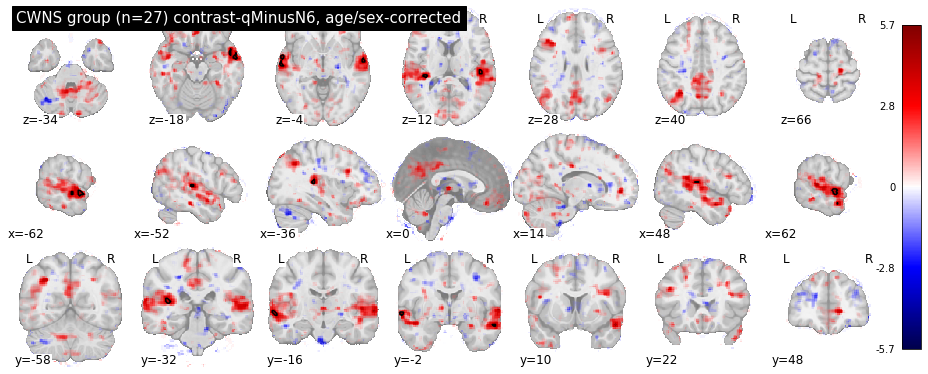

In [26]:
z_map_cwns, thresh_cwns, zthresh_cwns = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWNS'))

plot_mosaic_with_contours(
    z_map_cwns, thresh_cwns, zthresh_cwns, ALPHA,
    title=(f'CWNS group (n={n_cwns}) contrast-qMinusN6, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, f'group-cwns_contrast-{contrast_label}_view-mosaic.png'),
)

### CWS speaking group

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:62: UserWarning: empty mask
  display.add_contours(


FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=4.78


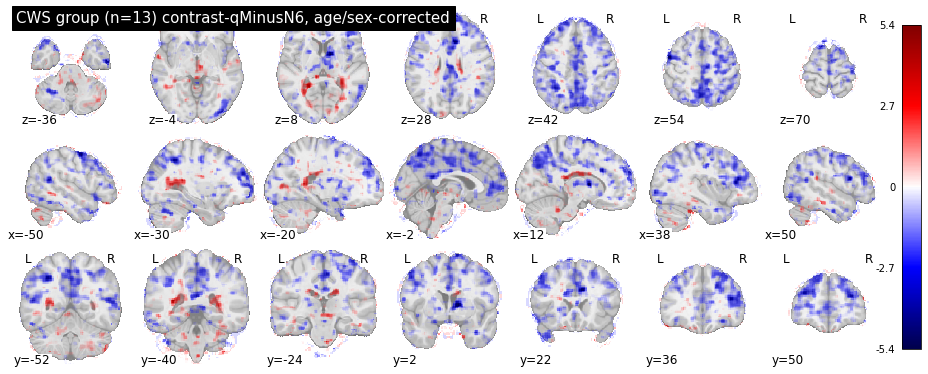

In [27]:
z_map_cws, thresh_cws, zthresh_cws = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS'))

plot_mosaic_with_contours(
    z_map_cws, thresh_cws, zthresh_cws, ALPHA,
    title=(f'CWS group (n={n_cws}) contrast-qMinusN6, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, f'group-cws_contrast-{contrast_label}_view-mosaic.png'),
)

### Group differences (CWS vs. CWNS)

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:31: UserWarning: The given float value must not exceed 5.158675666980766. But, you have given threshold=inf.
  thresholded_map, zthresh = threshold_stats_img(
/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:62: UserWarning: empty mask
  display.add_contours(


FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=inf


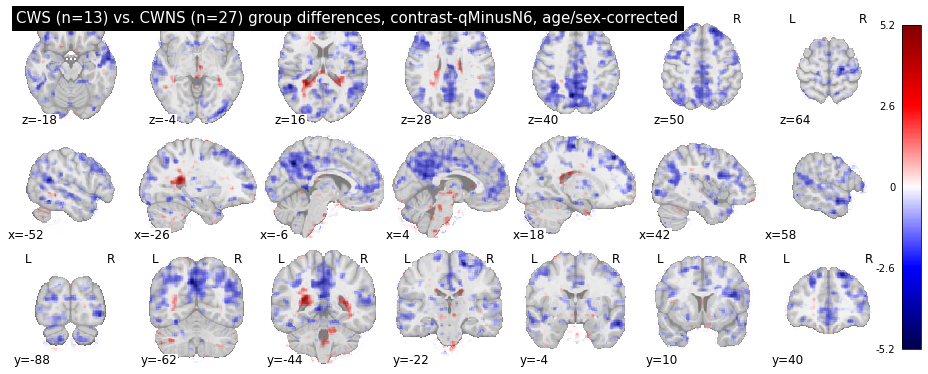

In [28]:
z_map_diff, thresh_diff, zthresh_diff = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS', 'CWNS'))

plot_mosaic_with_contours(
    z_map_diff, thresh_diff, zthresh_diff, ALPHA,
    title=(f'CWS (n={n_cws}) vs. CWNS (n={n_cwns}) group differences, '
          f'contrast-qMinusN6, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, f'group-diff_contrast-{contrast_label}_view-mosaic.png'),
)

## contrast-qMinus0

### Get files, fit model

In [29]:
contrast_label = 'qMinus0'
l1_dir = os.path.join(nilearn_dir, 'run-all_contrast-snr')
print(l1_dir)

l1_fnames, design_df = prepare_group_inputs(l1_dir, task_label, contrast_label, subjects_label,
                                            cov_design_df, design_columns)
second_level_model = SecondLevelModel().fit(l1_fnames, design_matrix=design_df)

n_cws = int(design_df['CWS'].sum())
n_cwns = int(design_df['CWNS'].sum())
corrected_for = 'age/sex' + ('/motion' if has_motion_covariate else '')
print(f'n_cws={n_cws}, n_cwns={n_cwns}, corrected for: {corrected_for}')

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/run-all_contrast-snr
Dropping 17 subject(s) with no contrast-qMinus0 effect map on disk (not every subject has every contrast -- e.g. a run excluded for motion, or first-level not yet finished for them): ['sub-SSP001', 'sub-SSP002', 'sub-SSP005', 'sub-SSP012', 'sub-SSP014', 'sub-SSP034', 'sub-SSP051', 'sub-SSP062', 'sub-SSP076', 'sub-SSP077', 'sub-SSP081', 'sub-SSP092', 'sub-SSP097', 'sub-SSP102', 'sub-SSP106', 'sub-SSP107', 'sub-SSP111']
n_cws=13, n_cwns=27, corrected for: age/sex


### CWNS speaking group

FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=3.19


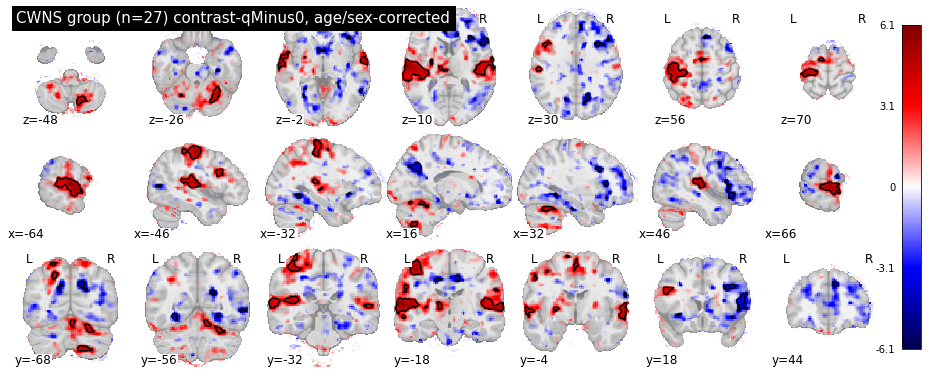

In [30]:
z_map_cwns, thresh_cwns, zthresh_cwns = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWNS'))

plot_mosaic_with_contours(
    z_map_cwns, thresh_cwns, zthresh_cwns, ALPHA,
    title=(f'CWNS group (n={n_cwns}) contrast-qMinus0, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, f'group-cwns_contrast-{contrast_label}_view-mosaic.png'),
)

### CWS speaking group

FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=4.19


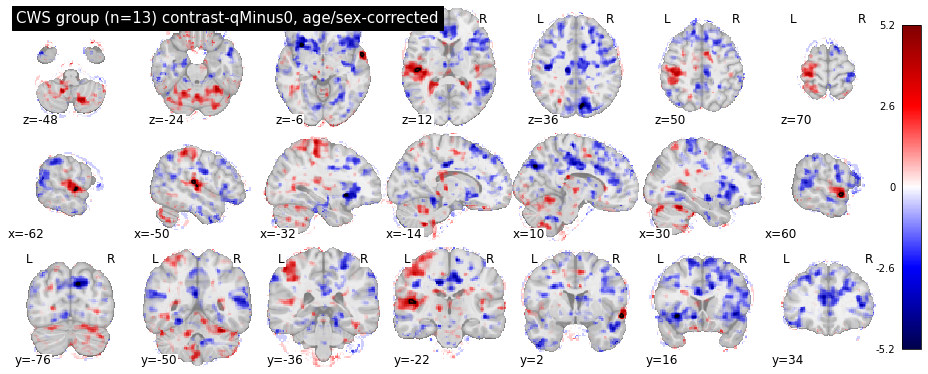

In [31]:
z_map_cws, thresh_cws, zthresh_cws = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS'))

plot_mosaic_with_contours(
    z_map_cws, thresh_cws, zthresh_cws, ALPHA,
    title=(f'CWS group (n={n_cws}) contrast-qMinus0, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, f'group-cws_contrast-{contrast_label}_view-mosaic.png'),
)

### Group differences (CWS vs. CWNS)

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:31: UserWarning: The given float value must not exceed 4.194267887422077. But, you have given threshold=inf.
  thresholded_map, zthresh = threshold_stats_img(
/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:62: UserWarning: empty mask
  display.add_contours(


FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=inf


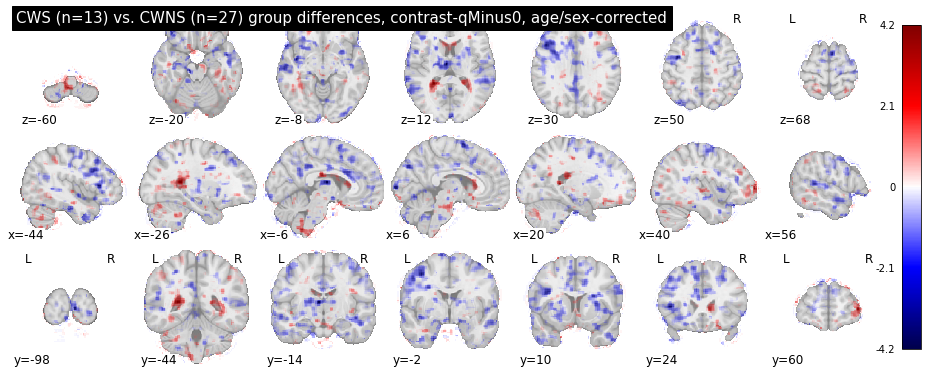

In [32]:
z_map_diff, thresh_diff, zthresh_diff = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS', 'CWNS'))

plot_mosaic_with_contours(
    z_map_diff, thresh_diff, zthresh_diff, ALPHA,
    title=(f'CWS (n={n_cws}) vs. CWNS (n={n_cwns}) group differences, '
          f'contrast-qMinus0, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, f'group-diff_contrast-{contrast_label}_view-mosaic.png'),
)

## contrast-snrTrend

### Compute per-subject linear SNR-trend maps

Parametric linear contrast across all 5 SNR levels, complementing the two-endpoint
`qMinusN6`/`qMinus0` difference contrasts above. Computed here as image arithmetic on the
already-existing per-condition first-level maps (`q`, `8`, `0`, `n2`, `n6`) rather than as a
new first-level GLM contrast -- mathematically equivalent, since contrasts are linear in the
beta estimates and all 5 conditions come from the same single per-subject GLM fit, so no
first-level rerun is needed. Same weights/order as the ROI-level trend in
`group_level_all_ROI.ipynb` (q > 8 > 0 > n2 > n6, cleanest to noisiest; positive trend = more
activation when cleaner). Written once per subject to disk as its own contrast, so the existing
`prepare_group_inputs`/`compute_group_contrast`/`plot_mosaic_with_contours` pipeline below can
treat it exactly like any other contrast, unchanged.

In [33]:
SNR_TREND_WEIGHTS = {'q': 2, '8': 1, '0': 0, 'n2': -1, 'n6': -2}

l1_dir = os.path.join(nilearn_dir, 'run-all_contrast-snr')
n_written, n_skipped, n_cached = 0, 0, 0
for sub_id in subjects_label:
    out_fpath = os.path.join(
        l1_dir, sub_id, f'{sub_id}_task-{task_label}_fwhm-6_contrast-snrTrend_stat-effect_statmap.nii.gz')
    if os.path.exists(out_fpath):
        n_cached += 1
        continue

    condition_fpaths = {}
    for snr_label in SNR_TREND_WEIGHTS:
        pattern = (l1_dir + f'/{sub_id}/{sub_id}_task-{task_label}_fwhm-6_'
                  f'contrast-{snr_label}_stat-effect_statmap.nii.gz')
        matches = sorted(glob(pattern))
        if matches:
            condition_fpaths[snr_label] = matches[0]

    if len(condition_fpaths) != len(SNR_TREND_WEIGHTS):
        missing = sorted(set(SNR_TREND_WEIGHTS) - set(condition_fpaths))
        print(f'Skipping {sub_id}: missing contrast(s) {missing} needed for the SNR trend')
        n_skipped += 1
        continue

    kwargs = {f'img{i}': fpath for i, fpath in enumerate(condition_fpaths.values())}
    formula = ' + '.join(f'{SNR_TREND_WEIGHTS[snr]} * img{i}'
                        for i, snr in enumerate(condition_fpaths))
    trend_img = math_img(formula, **kwargs)
    trend_img.to_filename(out_fpath)
    n_written += 1

print(f'SNR-trend maps: {n_written} written, {n_cached} already cached, '
     f'{n_skipped} subject(s) skipped (missing a condition)')


Skipping sub-SSP001: missing contrast(s) ['0', '8', 'n2', 'n6', 'q'] needed for the SNR trend
Skipping sub-SSP002: missing contrast(s) ['0', '8', 'n2', 'n6', 'q'] needed for the SNR trend
Skipping sub-SSP005: missing contrast(s) ['0', '8', 'n2', 'n6', 'q'] needed for the SNR trend
Skipping sub-SSP012: missing contrast(s) ['0', '8', 'n2', 'n6', 'q'] needed for the SNR trend
Skipping sub-SSP014: missing contrast(s) ['0', '8', 'n2', 'n6', 'q'] needed for the SNR trend
Skipping sub-SSP034: missing contrast(s) ['0', '8', 'n2', 'n6', 'q'] needed for the SNR trend
Skipping sub-SSP051: missing contrast(s) ['0', '8', 'n2', 'n6', 'q'] needed for the SNR trend
Skipping sub-SSP062: missing contrast(s) ['0', '8', 'n2', 'n6', 'q'] needed for the SNR trend
Skipping sub-SSP076: missing contrast(s) ['0', '8', 'n2', 'n6', 'q'] needed for the SNR trend
Skipping sub-SSP077: missing contrast(s) ['0', '8', 'n2', 'n6', 'q'] needed for the SNR trend
Skipping sub-SSP081: missing contrast(s) ['0', '8', 'n2', 'n

### Get files, fit model

In [34]:
contrast_label = 'snrTrend'
l1_dir = os.path.join(nilearn_dir, 'run-all_contrast-snr')
print(l1_dir)

l1_fnames, design_df = prepare_group_inputs(l1_dir, task_label, contrast_label, subjects_label,
                                            cov_design_df, design_columns)
second_level_model = SecondLevelModel().fit(l1_fnames, design_matrix=design_df)

n_cws = int(design_df['CWS'].sum())
n_cwns = int(design_df['CWNS'].sum())
corrected_for = 'age/sex' + ('/motion' if has_motion_covariate else '')
print(f'n_cws={n_cws}, n_cwns={n_cwns}, corrected for: {corrected_for}')


/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/run-all_contrast-snr
Dropping 17 subject(s) with no contrast-snrTrend effect map on disk (not every subject has every contrast -- e.g. a run excluded for motion, or first-level not yet finished for them): ['sub-SSP001', 'sub-SSP002', 'sub-SSP005', 'sub-SSP012', 'sub-SSP014', 'sub-SSP034', 'sub-SSP051', 'sub-SSP062', 'sub-SSP076', 'sub-SSP077', 'sub-SSP081', 'sub-SSP092', 'sub-SSP097', 'sub-SSP102', 'sub-SSP106', 'sub-SSP107', 'sub-SSP111']
n_cws=13, n_cwns=27, corrected for: age/sex


### CWNS speaking group

FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=3.76


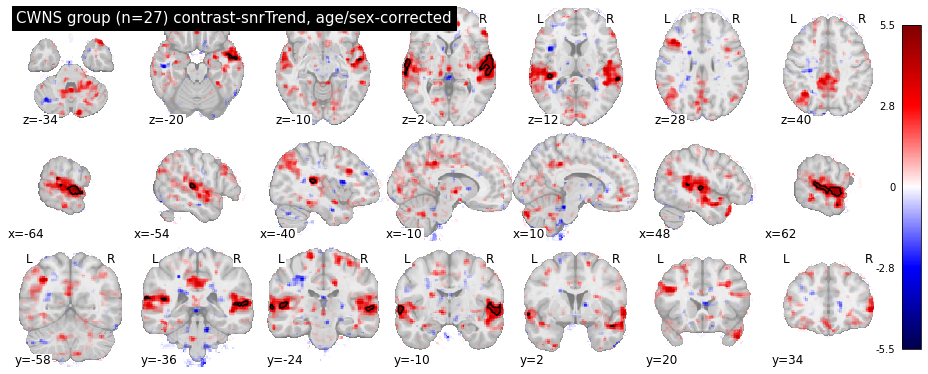

In [35]:
z_map_cwns, thresh_cwns, zthresh_cwns = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWNS'))

plot_mosaic_with_contours(
    z_map_cwns, thresh_cwns, zthresh_cwns, ALPHA,
    title=(f'CWNS group (n={n_cwns}) contrast-snrTrend, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, f'group-cwns_contrast-{contrast_label}_view-mosaic.png'),
)


### CWS speaking group

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:31: UserWarning: The given float value must not exceed 4.555263600392863. But, you have given threshold=inf.
  thresholded_map, zthresh = threshold_stats_img(
/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:62: UserWarning: empty mask
  display.add_contours(


FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=inf


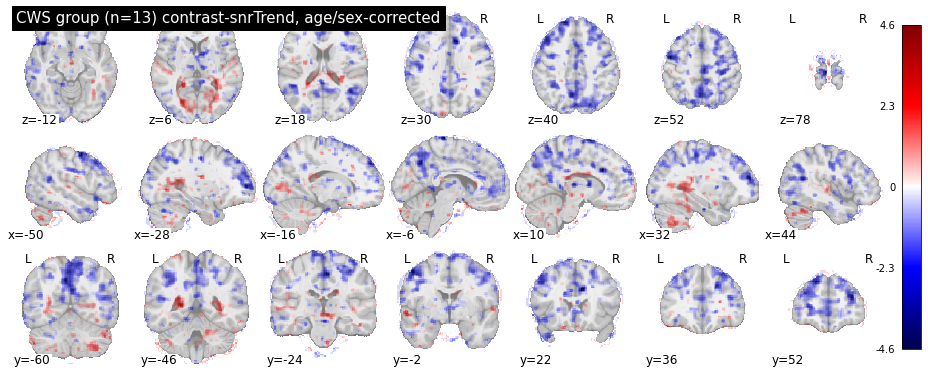

In [36]:
z_map_cws, thresh_cws, zthresh_cws = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS'))

plot_mosaic_with_contours(
    z_map_cws, thresh_cws, zthresh_cws, ALPHA,
    title=(f'CWS group (n={n_cws}) contrast-snrTrend, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, f'group-cws_contrast-{contrast_label}_view-mosaic.png'),
)


### Group differences (CWS vs. CWNS)

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:31: UserWarning: The given float value must not exceed 4.673252691986159. But, you have given threshold=inf.
  thresholded_map, zthresh = threshold_stats_img(
/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:62: UserWarning: empty mask
  display.add_contours(


FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=inf


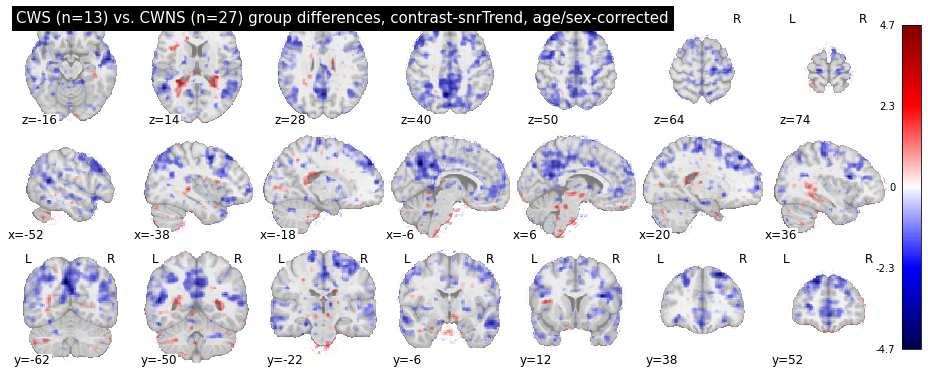

In [37]:
z_map_diff, thresh_diff, zthresh_diff = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS', 'CWNS'))

plot_mosaic_with_contours(
    z_map_diff, thresh_diff, zthresh_diff, ALPHA,
    title=(f'CWS (n={n_cws}) vs. CWNS (n={n_cwns}) group differences, '
          f'contrast-snrTrend, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, f'group-diff_contrast-{contrast_label}_view-mosaic.png'),
)


## contrast-q

### Get files, fit model

In [38]:
contrast_label = 'q'
l1_dir = os.path.join(nilearn_dir, 'run-all_contrast-snr')
print(l1_dir)

l1_fnames, design_df = prepare_group_inputs(l1_dir, task_label, contrast_label, subjects_label,
                                            cov_design_df, design_columns)
second_level_model = SecondLevelModel().fit(l1_fnames, design_matrix=design_df)

n_cws = int(design_df['CWS'].sum())
n_cwns = int(design_df['CWNS'].sum())
corrected_for = 'age/sex' + ('/motion' if has_motion_covariate else '')
print(f'n_cws={n_cws}, n_cwns={n_cwns}, corrected for: {corrected_for}')

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/run-all_contrast-snr
Dropping 17 subject(s) with no contrast-q effect map on disk (not every subject has every contrast -- e.g. a run excluded for motion, or first-level not yet finished for them): ['sub-SSP001', 'sub-SSP002', 'sub-SSP005', 'sub-SSP012', 'sub-SSP014', 'sub-SSP034', 'sub-SSP051', 'sub-SSP062', 'sub-SSP076', 'sub-SSP077', 'sub-SSP081', 'sub-SSP092', 'sub-SSP097', 'sub-SSP102', 'sub-SSP106', 'sub-SSP107', 'sub-SSP111']
n_cws=13, n_cwns=27, corrected for: age/sex


### CWNS speaking group

FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=3.19


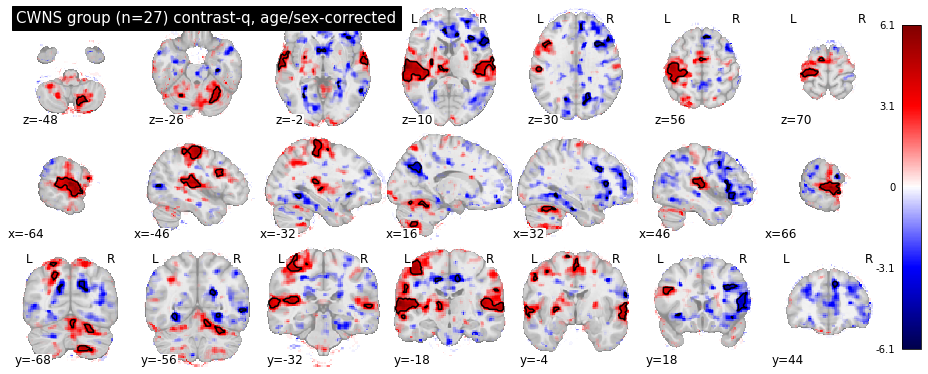

In [39]:
z_map_cwns, thresh_cwns, zthresh_cwns = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWNS'))

plot_mosaic_with_contours(
    z_map_cwns, thresh_cwns, zthresh_cwns, ALPHA,
    title=(f'CWNS group (n={n_cwns}) contrast-q, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cwns_contrast-q_view-mosaic.png'),
)

### CWS speaking group

FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=4.19


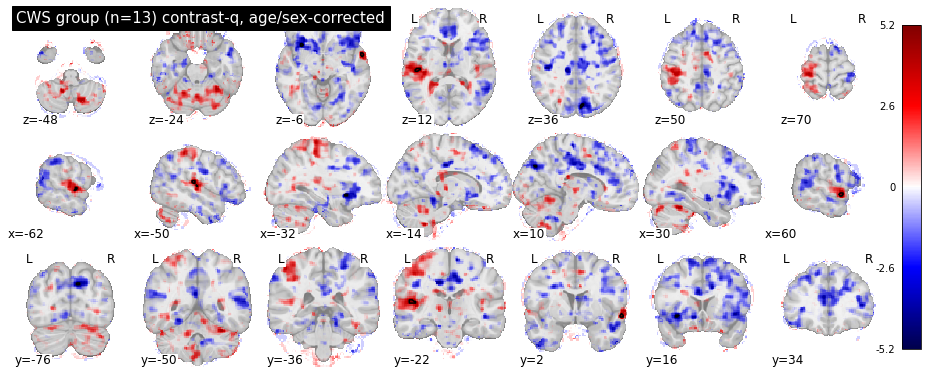

In [40]:
z_map_cws, thresh_cws, zthresh_cws = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS'))

plot_mosaic_with_contours(
    z_map_cws, thresh_cws, zthresh_cws, ALPHA,
    title=(f'CWS group (n={n_cws}) contrast-q, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cws_contrast-q_view-mosaic.png'),
)

### Group differences (CWS vs. CWNS)

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:31: UserWarning: The given float value must not exceed 4.194267887422077. But, you have given threshold=inf.
  thresholded_map, zthresh = threshold_stats_img(
/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:62: UserWarning: empty mask
  display.add_contours(


FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=inf


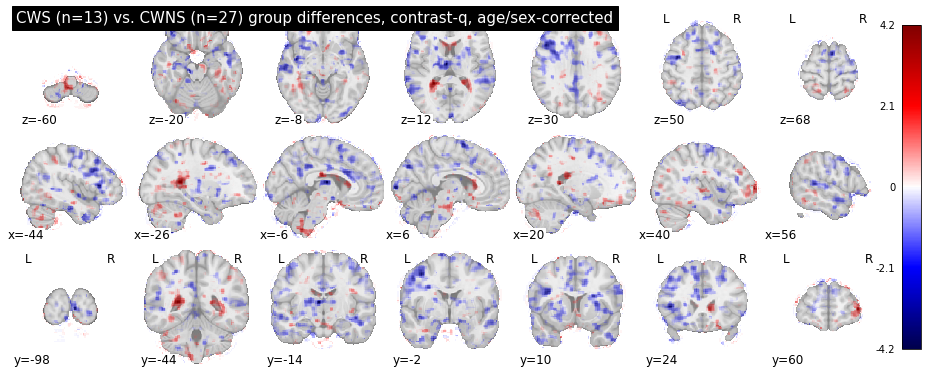

In [41]:
z_map_diff, thresh_diff, zthresh_diff = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS', 'CWNS'))

plot_mosaic_with_contours(
    z_map_diff, thresh_diff, zthresh_diff, ALPHA,
    title=(f'CWS (n={n_cws}) vs. CWNS (n={n_cwns}) group differences, '
          f'contrast-q, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-diff_contrast-q_view-mosaic.png'),
)

## contrast-8

### Get files, fit model

In [42]:
contrast_label = '8'
l1_dir = os.path.join(nilearn_dir, 'run-all_contrast-snr')
print(l1_dir)

l1_fnames, design_df = prepare_group_inputs(l1_dir, task_label, contrast_label, subjects_label,
                                            cov_design_df, design_columns)
second_level_model = SecondLevelModel().fit(l1_fnames, design_matrix=design_df)

n_cws = int(design_df['CWS'].sum())
n_cwns = int(design_df['CWNS'].sum())
corrected_for = 'age/sex' + ('/motion' if has_motion_covariate else '')
print(f'n_cws={n_cws}, n_cwns={n_cwns}, corrected for: {corrected_for}')

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/run-all_contrast-snr
Dropping 17 subject(s) with no contrast-8 effect map on disk (not every subject has every contrast -- e.g. a run excluded for motion, or first-level not yet finished for them): ['sub-SSP001', 'sub-SSP002', 'sub-SSP005', 'sub-SSP012', 'sub-SSP014', 'sub-SSP034', 'sub-SSP051', 'sub-SSP062', 'sub-SSP076', 'sub-SSP077', 'sub-SSP081', 'sub-SSP092', 'sub-SSP097', 'sub-SSP102', 'sub-SSP106', 'sub-SSP107', 'sub-SSP111']
n_cws=13, n_cwns=27, corrected for: age/sex


### CWNS speaking group

FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=3.64


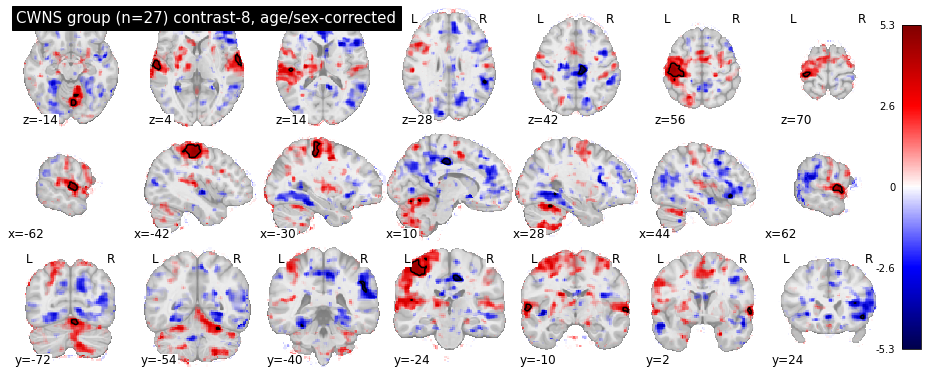

In [43]:
z_map_cwns, thresh_cwns, zthresh_cwns = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWNS'))

plot_mosaic_with_contours(
    z_map_cwns, thresh_cwns, zthresh_cwns, ALPHA,
    title=(f'CWNS group (n={n_cwns}) contrast-8, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cwns_contrast-8_view-mosaic.png'),
)

### CWS speaking group

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:31: UserWarning: The given float value must not exceed 4.967409977863715. But, you have given threshold=inf.
  thresholded_map, zthresh = threshold_stats_img(
/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:62: UserWarning: empty mask
  display.add_contours(


FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=inf


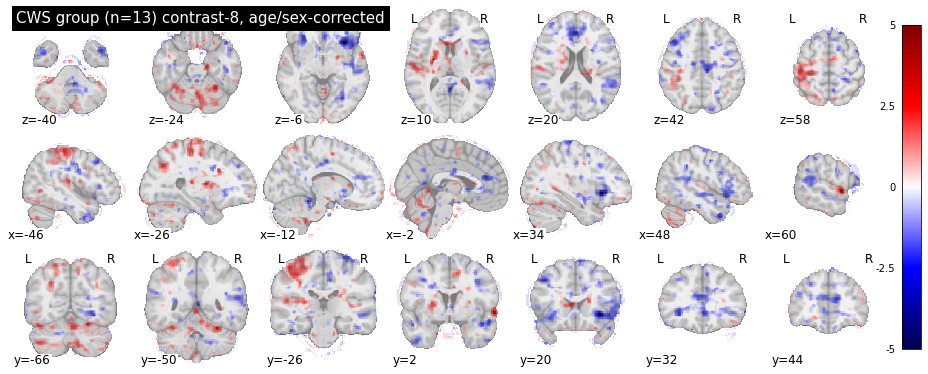

In [44]:
z_map_cws, thresh_cws, zthresh_cws = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS'))

plot_mosaic_with_contours(
    z_map_cws, thresh_cws, zthresh_cws, ALPHA,
    title=(f'CWS group (n={n_cws}) contrast-8, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cws_contrast-8_view-mosaic.png'),
)

### Group differences (CWS vs. CWNS)

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:31: UserWarning: The given float value must not exceed 4.153793221828679. But, you have given threshold=inf.
  thresholded_map, zthresh = threshold_stats_img(
/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:62: UserWarning: empty mask
  display.add_contours(


FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=inf


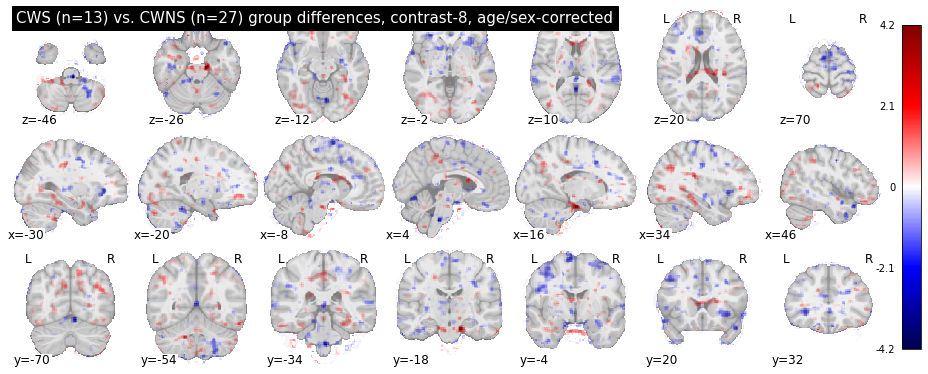

In [45]:
z_map_diff, thresh_diff, zthresh_diff = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS', 'CWNS'))

plot_mosaic_with_contours(
    z_map_diff, thresh_diff, zthresh_diff, ALPHA,
    title=(f'CWS (n={n_cws}) vs. CWNS (n={n_cwns}) group differences, '
          f'contrast-8, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-diff_contrast-8_view-mosaic.png'),
)

## contrast-0

### Get files, fit model

In [46]:
contrast_label = '0'
l1_dir = os.path.join(nilearn_dir, 'run-all_contrast-snr')
print(l1_dir)

l1_fnames, design_df = prepare_group_inputs(l1_dir, task_label, contrast_label, subjects_label,
                                            cov_design_df, design_columns)
second_level_model = SecondLevelModel().fit(l1_fnames, design_matrix=design_df)

n_cws = int(design_df['CWS'].sum())
n_cwns = int(design_df['CWNS'].sum())
corrected_for = 'age/sex' + ('/motion' if has_motion_covariate else '')
print(f'n_cws={n_cws}, n_cwns={n_cwns}, corrected for: {corrected_for}')

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/run-all_contrast-snr
Dropping 17 subject(s) with no contrast-0 effect map on disk (not every subject has every contrast -- e.g. a run excluded for motion, or first-level not yet finished for them): ['sub-SSP001', 'sub-SSP002', 'sub-SSP005', 'sub-SSP012', 'sub-SSP014', 'sub-SSP034', 'sub-SSP051', 'sub-SSP062', 'sub-SSP076', 'sub-SSP077', 'sub-SSP081', 'sub-SSP092', 'sub-SSP097', 'sub-SSP102', 'sub-SSP106', 'sub-SSP107', 'sub-SSP111']
n_cws=13, n_cwns=27, corrected for: age/sex


### CWNS speaking group

FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=3.84


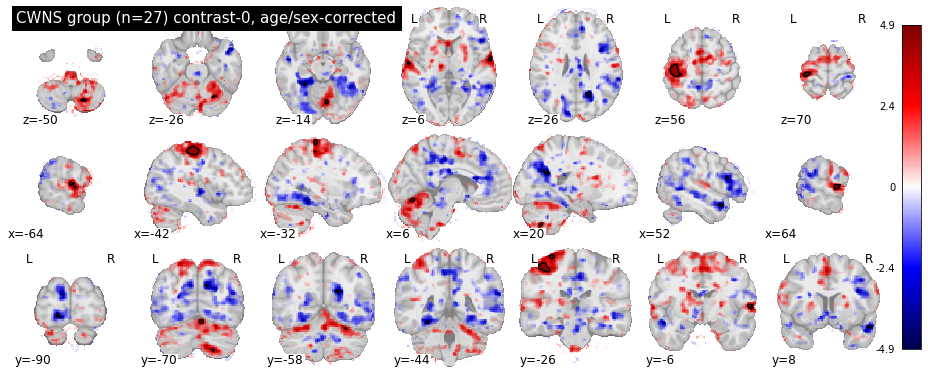

In [47]:
z_map_cwns, thresh_cwns, zthresh_cwns = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWNS'))

plot_mosaic_with_contours(
    z_map_cwns, thresh_cwns, zthresh_cwns, ALPHA,
    title=(f'CWNS group (n={n_cwns}) contrast-0, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cwns_contrast-0_view-mosaic.png'),
)

### CWS speaking group

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:62: UserWarning: empty mask
  display.add_contours(


FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=5.26


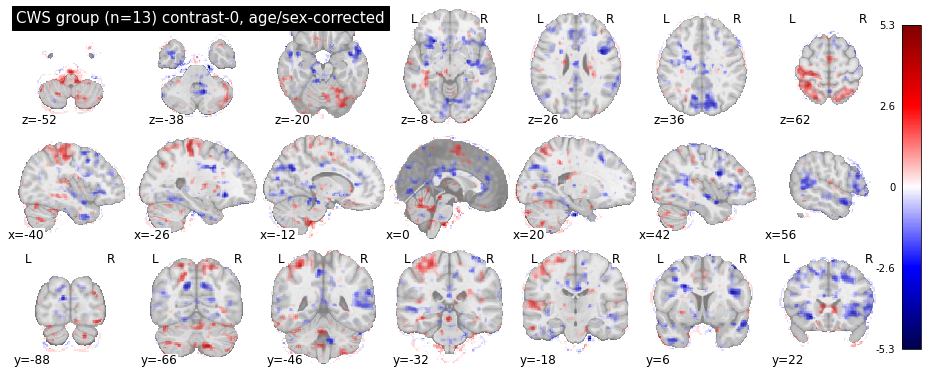

In [48]:
z_map_cws, thresh_cws, zthresh_cws = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS'))

plot_mosaic_with_contours(
    z_map_cws, thresh_cws, zthresh_cws, ALPHA,
    title=(f'CWS group (n={n_cws}) contrast-0, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cws_contrast-0_view-mosaic.png'),
)

### Group differences (CWS vs. CWNS)

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:31: UserWarning: The given float value must not exceed 4.077538969426271. But, you have given threshold=inf.
  thresholded_map, zthresh = threshold_stats_img(
/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:62: UserWarning: empty mask
  display.add_contours(


FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=inf


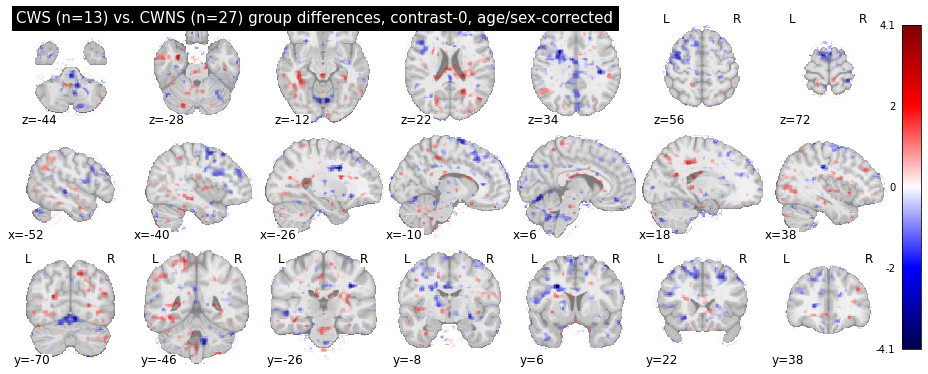

In [49]:
z_map_diff, thresh_diff, zthresh_diff = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS', 'CWNS'))

plot_mosaic_with_contours(
    z_map_diff, thresh_diff, zthresh_diff, ALPHA,
    title=(f'CWS (n={n_cws}) vs. CWNS (n={n_cwns}) group differences, '
          f'contrast-0, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-diff_contrast-0_view-mosaic.png'),
)

## contrast-n2

### Get files, fit model

In [50]:
contrast_label = 'n2'
l1_dir = os.path.join(nilearn_dir, 'run-all_contrast-snr')
print(l1_dir)

l1_fnames, design_df = prepare_group_inputs(l1_dir, task_label, contrast_label, subjects_label,
                                            cov_design_df, design_columns)
second_level_model = SecondLevelModel().fit(l1_fnames, design_matrix=design_df)

n_cws = int(design_df['CWS'].sum())
n_cwns = int(design_df['CWNS'].sum())
corrected_for = 'age/sex' + ('/motion' if has_motion_covariate else '')
print(f'n_cws={n_cws}, n_cwns={n_cwns}, corrected for: {corrected_for}')

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/run-all_contrast-snr
Dropping 17 subject(s) with no contrast-n2 effect map on disk (not every subject has every contrast -- e.g. a run excluded for motion, or first-level not yet finished for them): ['sub-SSP001', 'sub-SSP002', 'sub-SSP005', 'sub-SSP012', 'sub-SSP014', 'sub-SSP034', 'sub-SSP051', 'sub-SSP062', 'sub-SSP076', 'sub-SSP077', 'sub-SSP081', 'sub-SSP092', 'sub-SSP097', 'sub-SSP102', 'sub-SSP106', 'sub-SSP107', 'sub-SSP111']
n_cws=13, n_cwns=27, corrected for: age/sex


### CWNS speaking group

FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=3.34


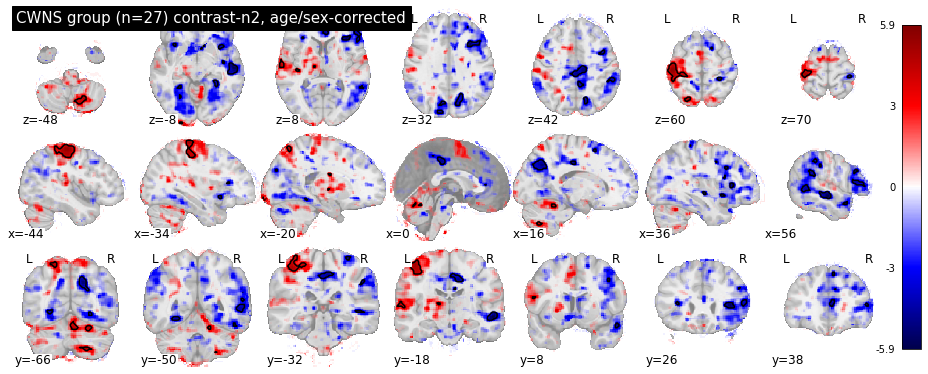

In [51]:
z_map_cwns, thresh_cwns, zthresh_cwns = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWNS'))

plot_mosaic_with_contours(
    z_map_cwns, thresh_cwns, zthresh_cwns, ALPHA,
    title=(f'CWNS group (n={n_cwns}) contrast-n2, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cwns_contrast-n2_view-mosaic.png'),
)

### CWS speaking group

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:31: UserWarning: The given float value must not exceed 5.065734015346067. But, you have given threshold=inf.
  thresholded_map, zthresh = threshold_stats_img(
/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:62: UserWarning: empty mask
  display.add_contours(


FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=inf


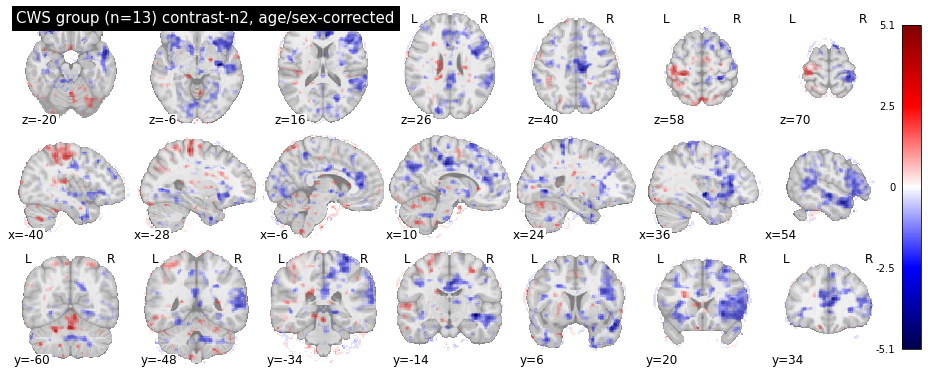

In [52]:
z_map_cws, thresh_cws, zthresh_cws = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS'))

plot_mosaic_with_contours(
    z_map_cws, thresh_cws, zthresh_cws, ALPHA,
    title=(f'CWS group (n={n_cws}) contrast-n2, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cws_contrast-n2_view-mosaic.png'),
)

### Group differences (CWS vs. CWNS)

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:31: UserWarning: The given float value must not exceed 4.083442678317381. But, you have given threshold=inf.
  thresholded_map, zthresh = threshold_stats_img(
/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:62: UserWarning: empty mask
  display.add_contours(


FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=inf


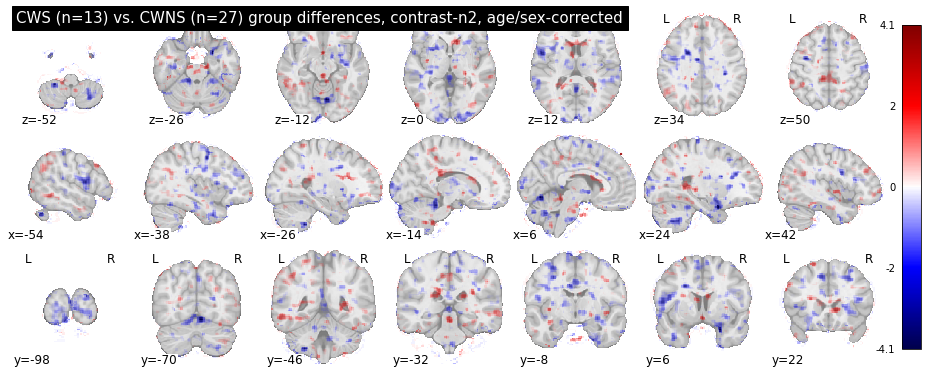

In [53]:
z_map_diff, thresh_diff, zthresh_diff = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS', 'CWNS'))

plot_mosaic_with_contours(
    z_map_diff, thresh_diff, zthresh_diff, ALPHA,
    title=(f'CWS (n={n_cws}) vs. CWNS (n={n_cwns}) group differences, '
          f'contrast-n2, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-diff_contrast-n2_view-mosaic.png'),
)

## contrast-n6

### Get files, fit model

In [54]:
contrast_label = 'n6'
l1_dir = os.path.join(nilearn_dir, 'run-all_contrast-snr')
print(l1_dir)

l1_fnames, design_df = prepare_group_inputs(l1_dir, task_label, contrast_label, subjects_label,
                                            cov_design_df, design_columns)
second_level_model = SecondLevelModel().fit(l1_fnames, design_matrix=design_df)

n_cws = int(design_df['CWS'].sum())
n_cwns = int(design_df['CWNS'].sum())
corrected_for = 'age/sex' + ('/motion' if has_motion_covariate else '')
print(f'n_cws={n_cws}, n_cwns={n_cwns}, corrected for: {corrected_for}')

/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/run-all_contrast-snr
Dropping 17 subject(s) with no contrast-n6 effect map on disk (not every subject has every contrast -- e.g. a run excluded for motion, or first-level not yet finished for them): ['sub-SSP001', 'sub-SSP002', 'sub-SSP005', 'sub-SSP012', 'sub-SSP014', 'sub-SSP034', 'sub-SSP051', 'sub-SSP062', 'sub-SSP076', 'sub-SSP077', 'sub-SSP081', 'sub-SSP092', 'sub-SSP097', 'sub-SSP102', 'sub-SSP106', 'sub-SSP107', 'sub-SSP111']
n_cws=13, n_cwns=27, corrected for: age/sex


### CWNS speaking group

FDR alpha=0.05 cluster-corrected (>10 voxels) threshold z=3.53


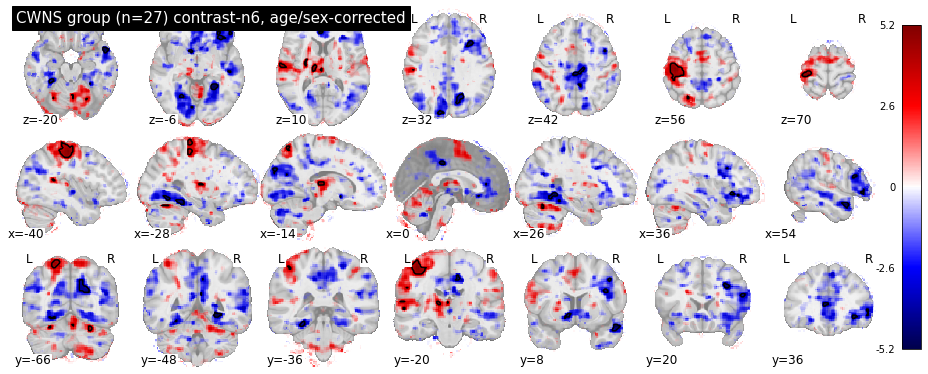

In [55]:
z_map_cwns, thresh_cwns, zthresh_cwns = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWNS'))

plot_mosaic_with_contours(
    z_map_cwns, thresh_cwns, zthresh_cwns, ALPHA,
    title=(f'CWNS group (n={n_cwns}) contrast-n6, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cwns_contrast-n6_view-mosaic.png'),
)

### CWS speaking group

/scratch/slurm-10697909/ipykernel_2514751/3468098291.py:31: UserWarning: The given float value must not exceed 4.7685516550037725. But, you have given threshold=inf.
  thresholded_map, zthresh = threshold_stats_img(


ValueError: alpha must be between 0 and 1, inclusive, but min is 0.0, max is 1.0000001192092896

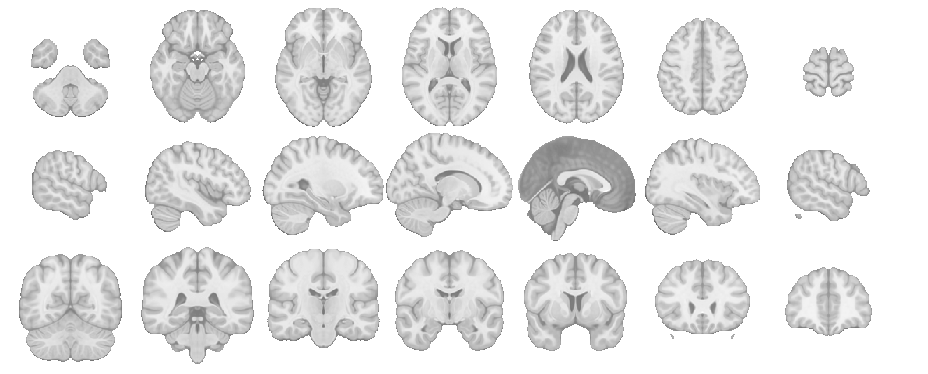

In [56]:
z_map_cws, thresh_cws, zthresh_cws = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS'))

plot_mosaic_with_contours(
    z_map_cws, thresh_cws, zthresh_cws, ALPHA,
    title=(f'CWS group (n={n_cws}) contrast-n6, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cws_contrast-n6_view-mosaic.png'),
)

### Group differences (CWS vs. CWNS)

In [ ]:
z_map_diff, thresh_diff, zthresh_diff = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS', 'CWNS'))

plot_mosaic_with_contours(
    z_map_diff, thresh_diff, zthresh_diff, ALPHA,
    title=(f'CWS (n={n_cws}) vs. CWNS (n={n_cwns}) group differences, '
          f'contrast-n6, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-diff_contrast-n6_view-mosaic.png'),
)

## contrast-sound

### Get files, fit model

In [ ]:
contrast_label = 'sound'
l1_dir = os.path.join(nilearn_dir, 'run-all')
print(l1_dir)

l1_fnames, design_df = prepare_group_inputs(l1_dir, task_label, contrast_label, subjects_label,
                                            cov_design_df, design_columns)
second_level_model = SecondLevelModel().fit(l1_fnames, design_matrix=design_df)

n_cws = int(design_df['CWS'].sum())
n_cwns = int(design_df['CWNS'].sum())
corrected_for = 'age/sex' + ('/motion' if has_motion_covariate else '')
print(f'n_cws={n_cws}, n_cwns={n_cwns}, corrected for: {corrected_for}')

### CWNS speaking group

In [ ]:
z_map_cwns, thresh_cwns, zthresh_cwns = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWNS'))

plot_mosaic_with_contours(
    z_map_cwns, thresh_cwns, zthresh_cwns, ALPHA,
    title=(f'CWNS group (n={n_cwns}) contrast-sound, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cwns_contrast-sound_view-mosaic.png'),
)

### CWS speaking group

In [ ]:
z_map_cws, thresh_cws, zthresh_cws = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS'))

plot_mosaic_with_contours(
    z_map_cws, thresh_cws, zthresh_cws, ALPHA,
    title=(f'CWS group (n={n_cws}) contrast-sound, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cws_contrast-sound_view-mosaic.png'),
)

### Group differences (CWS vs. CWNS)

In [ ]:
z_map_diff, thresh_diff, zthresh_diff = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS', 'CWNS'))

plot_mosaic_with_contours(
    z_map_diff, thresh_diff, zthresh_diff, ALPHA,
    title=(f'CWS (n={n_cws}) vs. CWNS (n={n_cwns}) group differences, '
          f'contrast-sound, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-diff_contrast-sound_view-mosaic.png'),
)

## contrast-response

### Get files, fit model

In [ ]:
contrast_label = 'response'
l1_dir = os.path.join(nilearn_dir, 'run-all')
print(l1_dir)

l1_fnames, design_df = prepare_group_inputs(l1_dir, task_label, contrast_label, subjects_label,
                                            cov_design_df, design_columns)
second_level_model = SecondLevelModel().fit(l1_fnames, design_matrix=design_df)

n_cws = int(design_df['CWS'].sum())
n_cwns = int(design_df['CWNS'].sum())
corrected_for = 'age/sex' + ('/motion' if has_motion_covariate else '')
print(f'n_cws={n_cws}, n_cwns={n_cwns}, corrected for: {corrected_for}')

### CWNS speaking group

In [ ]:
z_map_cwns, thresh_cwns, zthresh_cwns = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWNS'))

plot_mosaic_with_contours(
    z_map_cwns, thresh_cwns, zthresh_cwns, ALPHA,
    title=(f'CWNS group (n={n_cwns}) contrast-response, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cwns_contrast-response_view-mosaic.png'),
)

### CWS speaking group

In [ ]:
z_map_cws, thresh_cws, zthresh_cws = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS'))

plot_mosaic_with_contours(
    z_map_cws, thresh_cws, zthresh_cws, ALPHA,
    title=(f'CWS group (n={n_cws}) contrast-response, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-cws_contrast-response_view-mosaic.png'),
)

### Group differences (CWS vs. CWNS)

In [ ]:
z_map_diff, thresh_diff, zthresh_diff = compute_group_contrast(
    second_level_model, contrast_vector(design_df, 'CWS', 'CWNS'))

plot_mosaic_with_contours(
    z_map_diff, thresh_diff, zthresh_diff, ALPHA,
    title=(f'CWS (n={n_cws}) vs. CWNS (n={n_cwns}) group differences, '
          f'contrast-response, {corrected_for}-corrected'),
    out_fpath=os.path.join(group_out_dir, 'group-diff_contrast-response_view-mosaic.png'),
)